# Analyse de données multimodales d’athlètes

Trois sportifs ont été suivis pendant 6 mois.

Les données proviennent de plusieurs sources : un capteur Fitbit, des questionnaires remplis quotidiennement, des informations sur les séances d’entraînement, les blessures et les repas.

L’objectif est d’abord de regrouper et nettoyer toutes ces informations pour construire une table de données exploitable pour le machine learning.

2 objectifs sont ensuite étudiés : Le club aurait besoin de

* Est ce que le joueur peut t'il endosser une entrainement ?
=> prédire un indice représentant l’état de préparation du joueur à réaliser une bonne performance ;
* Est ce que le joueur risque t'il de se blesser?
=> prédire le risque de blessure:
Un rapport est disponible pour le raisonnement

In [80]:
import json
import numpy as np
import pandas as pd

from pathlib import Path
#extraire metadonnées image
from PIL import Image
from PIL.ExifTags import TAGS
#pour generer figures
import matplotlib.pyplot as plt
Path("figures").mkdir(exist_ok=True)
base = Path("data")
PARTICIPANTS = ["p01", "p03", "p05"]

## Premiere etape: Audit rapide avant aggregation

Avant toute modélisation, je vérifie la faisabilité :

- la structure des fichiers et leur présence  par participant
- la couverture temporelle (périodes manquantes, granularité de chaque source)
- le nombre d'événements exploitables (durée, type de blessures)

Cette étape produit un état des lieux et peut amener à redemander ou chercher des fichiers manquants

1.1 Verifier la presence des fichier par participant

In [81]:

# 1.0 — Presence des fichiers par participant
# Aucune liste de reference n'est codee en dur : l'attendu est deduit de
# l'union des fichiers presents chez l'ensemble des participants. Un fichier
# absent chez un seul sujet apparait ainsi comme manquant.

inventaire = {}
for pid in PARTICIPANTS:
    racine = base / pid
    d = {}
    for f in racine.rglob("*"):
        if not f.is_file() or f.name.startswith("."):
            continue
        d.setdefault(f.parent.relative_to(racine).as_posix(), []).append(f.name)
    inventaire[pid] = d

# un dossier dont le contenu varie fortement entre participants est une
# collection : on compare son volume, pas ses noms
tous_dossiers = sorted({d for inv in inventaire.values() for d in inv})

for dossier in tous_dossiers:
    tailles = [len(inventaire[p].get(dossier, [])) for p in PARTICIPANTS]
    collection = max(tailles) > 10

    if collection:
        print(f"\n{dossier} (collection)")
        for p, n in zip(PARTICIPANTS, tailles):
            print(f"  {p} : {n} fichiers")
    else:
        attendus = set().union(*(set(inventaire[p].get(dossier, [])) for p in PARTICIPANTS))
        print(f"\n{dossier}")
        for p in PARTICIPANTS:
            manque = sorted(attendus - set(inventaire[p].get(dossier, [])))
            print(f"  {p} : {'complet' if not manque else 'manque ' + ', '.join(manque)}")


fitbit
  p01 : complet
  p03 : manque heart_rate.json
  p05 : complet

food-images (collection)
  p01 : 321 fichiers
  p03 : 136 fichiers
  p05 : 186 fichiers

googledocs
  p01 : complet
  p03 : complet
  p05 : complet

pmsys
  p01 : complet
  p03 : complet
  p05 : complet


1.2 : Couverture temporelle :Période couverte, jours renseignés par le capteur, et volume des
déclarations pour chaque source.

In [82]:
#avant tout on regarde la couverture temporelle de chaque fichier
resume = []

for pid in PARTICIPANTS:
    with open(base / pid / "fitbit" / "steps.json", encoding="utf-8") as fh:
        steps = json.load(fh)
    dates = pd.to_datetime(pd.DataFrame(steps)["dateTime"]).dt.normalize()

    wellness = pd.read_csv(base / pid / "pmsys" / "wellness.csv")
    srpe = pd.read_csv(base / pid / "pmsys" / "srpe.csv")
    injury = pd.read_csv(base / pid / "pmsys" / "injury.csv")
    injury["positive"] = injury["injuries"] != "{}"

    resume.append({
        "participant": pid,
        "debut": dates.min().date(),
        "fin": dates.max().date(),
        "jours_fitbit": dates.nunique(),
        "n_wellness": len(wellness),
        "n_seances": len(srpe),
        "n_decl_blessure": len(injury),
        "n_blessures_pos": injury["positive"].sum(),
    })

audit = pd.DataFrame(resume)
audit

,participant,debut,fin,jours_fitbit,n_wellness,n_seances,n_decl_blessure,n_blessures_pos
0,p01,2019-11-01,2020-03-31,152,138,34,24,1
1,p03,2019-11-01,2020-03-31,122,82,2,11,0
2,p05,2019-11-01,2020-03-31,144,137,9,10,10


 1.2 Structure des sources

1.3 Regarder le nombre de jours manquants

In [83]:
periode_attendue = pd.date_range("2019-11-01", "2020-03-31", freq="D")

for pid in PARTICIPANTS:
    with open(base / pid / "fitbit" / "steps.json", encoding="utf-8") as fh:
        d = json.load(fh)
    dates = pd.to_datetime(pd.DataFrame(d)["dateTime"]).dt.normalize().unique()
    manquants = periode_attendue.difference(pd.DatetimeIndex(dates))

    print(f"\n{pid} : {len(manquants)} jours manquants")
    if len(manquants):
        print(manquants.strftime("%Y-%m-%d").tolist())


p01 : 0 jours manquants

p03 : 30 jours manquants
['2019-11-04', '2019-11-10', '2019-11-17', '2019-11-18', '2019-11-19', '2019-11-20', '2019-11-21', '2019-11-22', '2019-11-23', '2019-11-24', '2019-11-25', '2019-11-26', '2019-11-27', '2019-11-28', '2019-11-29', '2019-11-30', '2019-12-01', '2019-12-02', '2019-12-03', '2019-12-04', '2019-12-05', '2019-12-06', '2019-12-07', '2019-12-08', '2019-12-09', '2020-02-29', '2020-03-01', '2020-03-02', '2020-03-03', '2020-03-28']

p05 : 8 jours manquants
['2019-11-11', '2020-02-08', '2020-02-22', '2020-02-23', '2020-02-24', '2020-02-25', '2020-02-26', '2020-02-27']


1.4 Declaration de blessures : Nombre, durée et type de blessures exploitables


In [84]:
for pid in PARTICIPANTS:
    inj = pd.read_csv(base / pid / "pmsys" / "injury.csv")
    print(type(base), base)
    inj["date"] = pd.to_datetime(inj["effective_time_frame"]).dt.normalize()
    inj["positive"] = inj["injuries"] != "{}"
    inj["ecart_jours"] = inj["date"].diff().dt.days



   # print(f"\n{pid} {inj['positive'].sum()} positives sur {len(inj)} declarations")
    #print(inj[["date", "injuries", "ecart_jours"]].to_string(index=False))

<class 'pathlib.WindowsPath'> data
<class 'pathlib.WindowsPath'> data
<class 'pathlib.WindowsPath'> data


Vue d'ensemble de l'audit sous forme d'une figure

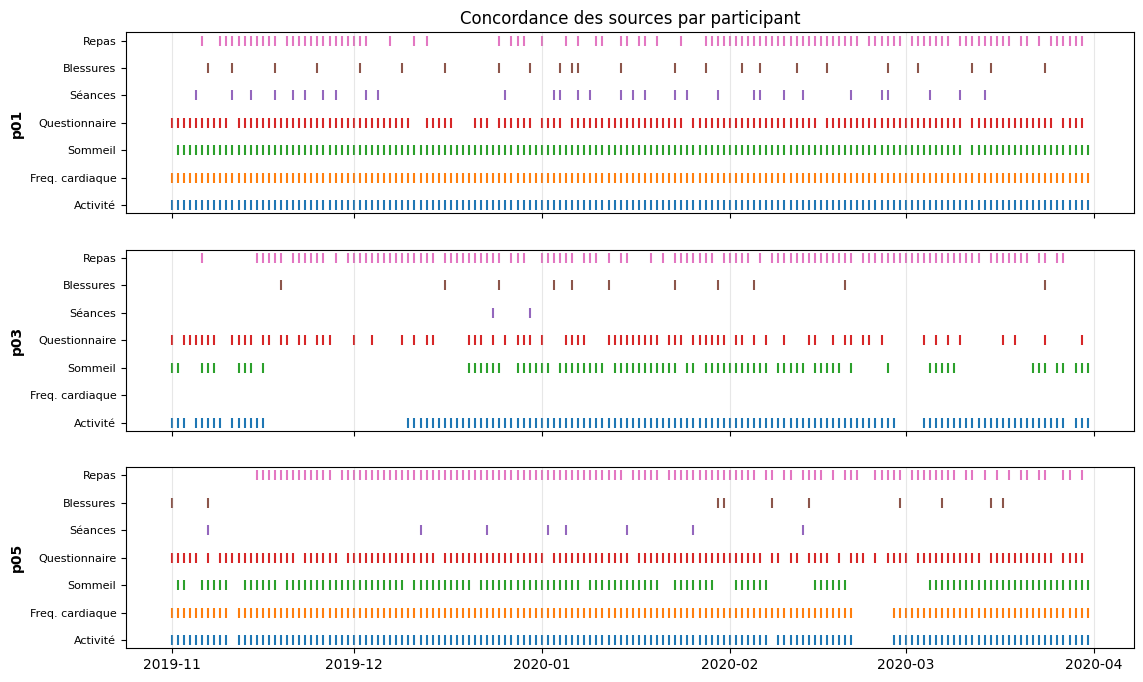

<Figure size 640x480 with 0 Axes>

In [85]:
sources = {
    "Activité": lambda pid: _dates_json(pid, "fitbit/steps.json"),
    "Freq. cardiaque": lambda pid: _dates_json(pid, "fitbit/heart_rate.json"),
    "Sommeil": lambda pid: _dates_sommeil(pid),
    "Questionnaire": lambda pid: _dates_csv(pid, "pmsys/wellness.csv", "effective_time_frame"),
    "Séances": lambda pid: _dates_csv(pid, "pmsys/srpe.csv", "end_date_time"),
    "Blessures": lambda pid: _dates_csv(pid, "pmsys/injury.csv", "effective_time_frame"),
    "Repas": lambda pid: _dates_csv(pid, "googledocs/reporting.csv", "date", dayfirst=True),
}

def _dates_json(pid, rel):
    f = base / pid / rel
    if not f.exists():
        return pd.DatetimeIndex([])
    with open(f, encoding="utf-8") as fh:
        d = json.load(fh)
    return pd.DatetimeIndex(pd.to_datetime(pd.DataFrame(d)["dateTime"]).dt.normalize().unique())

def _dates_sommeil(pid):
    with open(base / pid / "fitbit" / "sleep.json", encoding="utf-8") as fh:
        d = json.load(fh)
    return pd.DatetimeIndex(pd.to_datetime(pd.DataFrame(d)["dateOfSleep"]).unique())

def _dates_csv(pid, rel, col, dayfirst=False):
    f = base / pid / rel
    if not f.exists():
        return pd.DatetimeIndex([])
    t = pd.read_csv(f)
    dt = pd.to_datetime(t[col], utc=True, dayfirst=dayfirst).dt.tz_localize(None).dt.normalize()
    return pd.DatetimeIndex(dt.unique())

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

for ax, pid in zip(axes, PARTICIPANTS):
    for j, (nom, f) in enumerate(sources.items()):
        dates = f(pid)
        ax.scatter(dates, [j] * len(dates), marker="|", s=60)
    ax.set_yticks(range(len(sources)))
    ax.set_yticklabels(sources.keys(), fontsize=8)
    ax.set_ylabel(pid, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

axes[0].set_title("Concordance des sources par participant")
plt.savefig("figures/audit_participant.png", dpi=150, bbox_inches="tight")
plt.show()
plt.tight_layout()
plt.show()

### Conclusion de l'audit

**Couverture.** Même période pour les trois (nov. 2019 - mars 2020), mais
disponibilités inégales :
* 152   p01
*  144  p05
* 122  p03

Les manquants forment des blocs : 23 jours consécutifs chez p03, 6 chez p05
==>  périodes sans port du bracelet.

**Valeurs générées par le capteur.** `calories.json` compte exactement 218 880
lignes pour les trois, soit 152 jours × 1440 minutes. Fitbit produit une valeur
à chaque minute indépendamment du port. La complétude apparente est fausse.

**Charge d'entraînement.** sRPE renseigné sur 34, 9 et 2 séances. Inexploitable
comme indicateur comparable ; les données d'activité seront utilisées à la place.

**Blessures.** 45 déclarations, 11 positives : 1/24 chez p01, 0/11 chez p03,
10/10 chez p05. Les protocoles de déclaration diffèrent. Après regroupement des
déclarations consécutives sur une même zone, 4 épisodes distincts
subsistent, aucun ne présentant les caractéristiques d'une lésion de surcharge.

### À clarifier avec le fournisseur ou autre membre de l'equipe

- `heart_rate.json` absent chez p03 : fichier perdu à la livraison, ou données
  jamais collectées ?
- Protocole de déclaration des blessures : les participants devaient-ils
  renseigner l'absence de blessure ?
- Consigne de port du bracelet, notamment la nuit.

## 2.Datbase handling : Agrégation au pas participant-jour

Les sources ont des granularités différentes : la minute pour l'activité et la
fréquence cardiaque, l'événement pour les séances et les nuits, la journée pour
les questionnaires. Chacune est agrégée au pas journalier avec une statistique
adaptée.

La fusion s'appuie sur une grille complète de 152 jours par participant : les
jours sans données apparaissent en valeurs manquantes plutôt que de disparaître.

 2.1 Fonctions de chargement

Une fonction par source, regroupées ici. Chacune gère son propre nettoyage ,
types, encodages et agrège par jour.

In [86]:
def charger_flux_minute(chemin, nom, agg="sum"):
    """Agrège un flux Fitbit à la minute vers un pas journalier."""
    with open(chemin, encoding="utf-8") as fh:
        contenu = json.load(fh)
    df = pd.DataFrame(contenu)
    df["date"] = pd.to_datetime(df["dateTime"]).dt.normalize()
    df["value"] = pd.to_numeric(df["value"])
    return df.groupby("date")["value"].agg(agg).rename(nom)

p = base / "p01" / "fitbit"
steps = charger_flux_minute(p / "steps.json", "steps")
calories = charger_flux_minute(p / "calories.json", "calories")
distance = charger_flux_minute(p / "distance.json", "distance_cm")

pd.concat([steps, calories, distance], axis=1).head()

def charger_heart_rate(chemin):
    """Agrège la frequence cardiaque minute vers des statistiques journalieres."""
    with open(chemin, encoding="utf-8") as fh:
        contenu = json.load(fh)
    df = pd.DataFrame(contenu)
    df["date"] = pd.to_datetime(df["dateTime"]).dt.normalize()
    df["bpm"] = df["value"].apply(lambda v: v["bpm"])
    df["confiance"] = df["value"].apply(lambda v: v["confidence"])

    agg = df.groupby("date").agg(
        hr_mean=("bpm", "mean"),
        hr_min=("bpm", "min"),
        hr_max=("bpm", "max"),
        hr_std=("bpm", "std"),
        hr_n_mesures=("bpm", "size"),
        hr_confiance=("confiance", "mean"),
    )
    return agg

def charger_sommeil(chemin):
    """Extrait le resume des nuits de sommeil."""
    with open(chemin, encoding="utf-8") as fh:
        contenu = json.load(fh)
    df = pd.DataFrame(contenu)

    df["date_reveil"] = pd.to_datetime(df["dateOfSleep"])
    df["date"] = df["date_reveil"] - pd.Timedelta(days=1)

    def phase(v, nom):
        return v.get("summary", {}).get(nom, {}).get("minutes")

    df["sommeil_profond"] = df["levels"].apply(lambda v: phase(v, "deep"))
    df["sommeil_rem"] = df["levels"].apply(lambda v: phase(v, "rem"))
    df["sommeil_leger"] = df["levels"].apply(lambda v: phase(v, "light"))

    df = df[df["mainSleep"]]

    agg = df.groupby("date").agg(
        sommeil_min=("minutesAsleep", "sum"),
        sommeil_efficacite=("efficiency", "mean"),
        sommeil_profond=("sommeil_profond", "sum"),
        sommeil_rem=("sommeil_rem", "sum"),
        temps_au_lit=("timeInBed", "sum"),
        minutes_eveille=("minutesAwake", "sum"),
    )
    return agg


def charger_exercices(chemin):
    """Agrege les seances detectees par Fitbit au pas journalier."""
    with open(chemin, encoding="utf-8") as fh:
        contenu = json.load(fh)
    df = pd.DataFrame(contenu)

    df["date"] = pd.to_datetime(df["startTime"]).dt.normalize()
    df["duree_min"] = df["activeDuration"] / 60000

    agg = df.groupby("date").agg(
        ex_n_seances=("logId", "count"),
        ex_duree_min=("duree_min", "sum"),
        ex_calories=("calories", "sum"),
        ex_hr_moy=("averageHeartRate", "mean"),
    )
    return agg

def charger_zones_cardiaques(chemin):
    """Extrait les minutes passees dans chaque zone d'intensite."""
    with open(chemin, encoding="utf-8") as fh:
        contenu = json.load(fh)
    df = pd.DataFrame(contenu)
    df["date"] = pd.to_datetime(df["dateTime"]).dt.normalize()

    zones = df["value"].apply(lambda v: v["valuesInZones"]).apply(pd.Series)
    zones.columns = [c.lower() for c in zones.columns]
    zones["date"] = df["date"].values

    return zones.groupby("date").sum()

def charger_wellness(chemin):
    """Charge le questionnaire quotidien, au pas journalier."""
    df = pd.read_csv(chemin)

    # ecarte les soumissions entierement a zero : les echelles commencent a 1,
    # un formulaire tout a zero correspond a un envoi sans reponse
    echelles = ["fatigue", "mood", "sleep_quality", "soreness", "stress"]
    df = df[~(df[echelles] == 0).all(axis=1)]

    df["date"] = (pd.to_datetime(df["effective_time_frame"], utc=True)
                    .dt.normalize().dt.tz_localize(None))
    df["soreness_n_zones"] = df["soreness_area"].apply(
        lambda x: len(eval(x)) if pd.notna(x) else 0)

    cols = ["fatigue", "mood", "readiness", "sleep_duration_h",
            "sleep_quality", "soreness", "stress", "soreness_n_zones"]
    return df.groupby("date")[cols].mean()

def charger_srpe(chemin):
    """Calcule la charge d'entrainement declaree."""
    df = pd.read_csv(chemin)
    df["date"] = pd.to_datetime(df["end_date_time"], utc=True).dt.normalize().dt.tz_localize(None)
    df["srpe"] = df["perceived_exertion"] * df["duration_min"]
    return df.groupby("date").agg(
        srpe_total=("srpe", "sum"),
        srpe_n_seances=("srpe", "count"),
        srpe_duree=("duration_min", "sum"),
    )

def charger_blessures(chemin):
    """Extrait les declarations de blessure positives."""
    df = pd.read_csv(chemin)
    df["date"] = pd.to_datetime(df["effective_time_frame"], utc=True).dt.normalize().dt.tz_localize(None)
    df["blessure_declaree"] = (df["injuries"] != "{}").astype(int)
    return df.groupby("date")[["blessure_declaree"]].max()

def charger_si_existe(fonction, chemin, *args, **kwargs):
    """Retourne le resultat de la fonction, ou None si le fichier est absent."""
    if not Path(chemin).exists():
        print(f"  absent : {chemin.name}")
        return None
    return fonction(chemin, *args, **kwargs)



2.2 Données nutritionnelles et images

Objectif : déterminer les calories consommées par jour et par sportif.

**Métadonnées.** `lire_date_image` extrait la date et l'heure EXIF de chaque
photo. `charger_photos` les agrège au jour : nombre de prises, heures extrêmes,
fenêtre alimentaire : calculée seulement au-delà de trois clichés.

**Estimation calorique.** L'analyse du contenu visuel est écartée : 35,8 %
d'erreur moyenne pour les meilleurs modèles (Fridolfsson et al., 2025), pas
d'objet de calibration dans les photos, pas de vérité terrain pour valider. Mais des pistes sont proposés dans le rapport à discuter avec le chef d'equipe si faisable ou à tester.

L'apport est approché par bilan énergétique : à poids stable, la dépense mesurée
approxime l'apport, répartie selon les repas déclarés. Variable indicative, non
retenue comme prédicteur.


In [87]:

def lire_date_image(chemin):
    """Retourne la date de prise de vue depuis les metadonnees EXIF."""
    try:
        exif = Image.open(chemin)._getexif()
        if not exif:
            return None
        for tag_id, valeur in exif.items():
            if TAGS.get(tag_id) == "DateTimeOriginal":
                return pd.to_datetime(valeur, format="%Y:%m:%d %H:%M:%S")
    except Exception:
        return None
    return None

def charger_photos(dossier):
    """Agrege les prises alimentaires photographiees au pas journalier."""
    dossier = Path(dossier)
    if not dossier.exists():
        return None

    horodatages = [lire_date_image(f) for f in dossier.iterdir() if f.is_file()]
    horodatages = [d for d in horodatages if d is not None]
    if not horodatages:
        return None

    photos = pd.DataFrame({"horodatage": horodatages})
    photos["date"] = photos["horodatage"].dt.normalize()

    agg = photos.groupby("date").agg(
        n_photos=("horodatage", "count"),
        premiere_prise=("horodatage", "min"),
        derniere_prise=("horodatage", "max"),
    )

    agg["fenetre_alim_h"] = (
        (agg["derniere_prise"] - agg["premiere_prise"]).dt.total_seconds() / 3600
    )
    agg["heure_premiere"] = agg["premiere_prise"].dt.hour
    agg["heure_derniere"] = agg["derniere_prise"].dt.hour

    # une prise unique produit une amplitude nulle, non interpretable
    agg.loc[agg["n_photos"] < 3, "fenetre_alim_h"] = np.nan

    return agg[["n_photos", "fenetre_alim_h", "heure_premiere", "heure_derniere"]]



def charger_reporting(chemin):
    """Extrait la structure des prises alimentaires declarees."""
    df = pd.read_csv(chemin)
    df["date"] = pd.to_datetime(df["date"], dayfirst=True)

    for repas in ["Breakfast", "Lunch", "Dinner", "Evening"]:
        df[f"repas_{repas.lower()}"] = df["meals"].fillna("").str.contains(repas).astype(int)

    df["n_repas"] = df[[f"repas_{r}" for r in
                        ["breakfast", "lunch", "dinner", "evening"]]].sum(axis=1)

    df["alcool"] = (df["alcohol_consumed"].astype(str).str.lower()
                      .isin(["true", "yes", "1"]).astype(int))

    cols = ["n_repas", "repas_breakfast", "repas_lunch", "repas_dinner",
            "repas_evening", "weight", "glasses_of_fluid", "alcool"]
    return df.groupby("date")[cols].mean()

2.3 Fusion et nettoyage

Les sources sont assemblées sur une grille complète de 152 jours par
participant, puis deux corrections sont appliquées.

Les jours sans port du bracelet sont neutralisés : Fitbit y génère des calories
qui ne mesurent rien, seule la présence de pas attestant du port effectif
==> Une colonne conserve la trace de ces jours.

J'ai decide de propager sur 14 jours entre deux déclarations, durée
correspondant aux écarts observés entre relevés consécutifs.

In [88]:
def nettoyer(df):
    """Corrections appliquees apres la fusion des sources."""
    df = df.sort_values(["participant", "date"]).copy()

    # les calories generees par Fitbit les jours sans port ne mesurent rien ;
    # seule la presence de pas atteste du port effectif
    non_port = df["steps"].isna() | (df["steps"] == 0)
    cols_fitbit = ["steps", "calories", "distance_cm", "hr_mean",
                   "hr_min", "hr_max", "hr_std", "hr_n_mesures", "hr_confiance"]
    df.loc[non_port, [c for c in cols_fitbit if c in df.columns]] = np.nan
    df["fitbit_porte"] = (~non_port).astype(int)

    # etat de blessure propage sur 14 jours entre deux declarations
    df["blessure_etat"] = df.groupby("participant")["blessure_declaree"].ffill(limit=14)

    return df

In [89]:
def construire_table_participant(pid):
    """Assemble toutes les sources d'un participant au pas journalier."""
    f = base / pid / "fitbit"
    pm = base / pid / "pmsys"

    sources = [
        charger_si_existe(charger_flux_minute, f / "steps.json", "steps"),
        charger_si_existe(charger_flux_minute, f / "calories.json", "calories"),
        charger_si_existe(charger_flux_minute, f / "distance.json", "distance_cm"),
        charger_si_existe(charger_heart_rate, f / "heart_rate.json"),
        charger_si_existe(charger_sommeil, f / "sleep.json"),
        charger_si_existe(charger_exercices, f / "exercise.json"),
        charger_si_existe(charger_wellness, pm / "wellness.csv"),
        charger_si_existe(charger_srpe, pm / "srpe.csv"),
        charger_si_existe(charger_blessures, pm / "injury.csv"),
        charger_si_existe(charger_reporting, base / pid / "googledocs" / "reporting.csv"),
        charger_photos(base / pid / "food-images"),
    ]
    sources = [s for s in sources if s is not None]

    grille = pd.DataFrame(
        index=pd.date_range("2019-11-01", "2020-03-31", freq="D", name="date")
    )

    for s in sources:
        grille = grille.join(s, how="left")

    grille["participant"] = pid
    return grille.reset_index()


2.4 Construction de la table


In [90]:
tables = [construire_table_participant(pid) for pid in PARTICIPANTS]
df = pd.concat(tables, ignore_index=True)
df = nettoyer(df)
# avoir un apercue de la table
print(f"{df.shape[0]} lignes, {df.shape[1]} colonnes")
print(df["participant"].value_counts().to_string())

  absent : heart_rate.json
456 lignes, 47 colonnes
participant
p01    152
p03    152
p05    152


 Étape 3 : Vue d'ensemble de la base


3.1  Structure des données de la table

Dimensions, types de colonnes et répartition par famille de variables.

In [91]:
print(f"Dimensions : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Periode   : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Participants : {df['participant'].nunique()}\n")

print("Types de colonnes :")
print(df.dtypes.value_counts().to_string())

familles = {
    "Identification": ["participant", "date"],
    "Activite": [c for c in df.columns if c.startswith(("steps", "calories", "distance", "ex_"))],
    "Physiologie": [c for c in df.columns if c.startswith("hr_")],
    "Sommeil": [c for c in df.columns if "sommeil" in c or "lit" in c or "eveille" in c],
    "Questionnaire": ["fatigue", "mood", "readiness", "sleep_quality", "soreness", "stress"],
    "Nutrition": [c for c in df.columns if c.startswith(("repas", "n_repas", "glasses", "alcool", "weight", "n_photos"))],
    "Cibles": ["blessure_declaree", "blessure_etat"],
}

print("\nColonnes par famille :")
for nom, cols in familles.items():
    print(f"  {nom:16s} {len(cols):2d}")

Dimensions : 456 lignes, 47 colonnes
Periode   : 2019-11-01 -> 2020-03-31
Participants : 3

Types de colonnes :
float64           44
datetime64[ns]     1
object             1
int32              1

Colonnes par famille :
  Identification    2
  Activite          7
  Physiologie       6
  Sommeil           7
  Questionnaire     6
  Nutrition         9
  Cibles            2


3.2 Complétude :Pourcentage de valeurs disponible pour chaque variable et participant

In [92]:
completude = (df.groupby("participant")
                .apply(lambda g: g.notna().mean() * 100)
                .round(1).T)
completude

participant,p01,p03,p05
date,100.0,100.0,100.0
steps,100.0,78.9,94.7
calories,100.0,78.9,94.7
distance_cm,100.0,78.9,94.7
hr_mean,100.0,0.0,94.7
hr_min,100.0,0.0,94.7
hr_max,100.0,0.0,94.7
hr_std,100.0,0.0,94.7
hr_n_mesures,100.0,0.0,94.7
hr_confiance,100.0,0.0,94.7


3.3 Analyse statistique et distribution des variables (min, max IQR)

In [93]:
variables = ["steps", "calories", "distance_cm", "hr_mean", "hr_min", "hr_max",
             "sommeil_min", "sommeil_efficacite", "fatigue", "readiness",
             "soreness", "stress"]

df[variables].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
steps,416.0,10126.3,5048.9,6.0,7227.2,10437.5,13289.0,24846.0
calories,416.0,3286.9,643.9,1929.6,2892.2,3358.5,3730.3,5225.8
distance_cm,416.0,787860.1,400610.2,470.0,566623.8,815925.0,1025235.0,2058360.0
hr_mean,296.0,69.3,6.7,56.5,63.5,69.3,74.4,90.0
hr_min,296.0,45.8,4.1,30.0,44.0,46.0,48.0,68.0
hr_max,296.0,137.0,17.9,95.0,124.0,132.0,146.0,200.0
sommeil_min,345.0,374.6,92.3,58.0,329.0,364.0,403.0,864.0
sommeil_efficacite,345.0,95.8,2.6,85.0,94.0,96.0,98.0,100.0
fatigue,350.0,2.7,0.5,1.0,2.0,3.0,3.0,4.0
readiness,350.0,4.6,2.3,0.0,5.0,5.0,6.0,8.0


3.4 Figure de visualisation : Bilan pour complétude par participant

In [94]:
def fig_dis(var, participants=None):
    """Affiche la distribution d'une variable, par participant."""
    participants = participants or PARTICIPANTS

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    donnees = [df.loc[df["participant"] == p, var].dropna() for p in participants]
    axes[0].boxplot(donnees, labels=participants)
    axes[0].set_title(f"{var} : comparaison")

    for p, d in zip(participants, donnees):
        axes[1].hist(d, bins=25, alpha=0.5, label=p)
    axes[1].legend(fontsize=8)
    axes[1].set_title(f"{var} : forme")

    plt.tight_layout()
    plt.savefig(f"figures/distribution_{var}.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(df[df["participant"].isin(participants)]
            .groupby("participant")[var]
            .describe().round(1))

3.3 Distribution des variables par participant

Les histogrammes permettent d'identifier les distributions anormales et les
écarts de niveau entre participants.

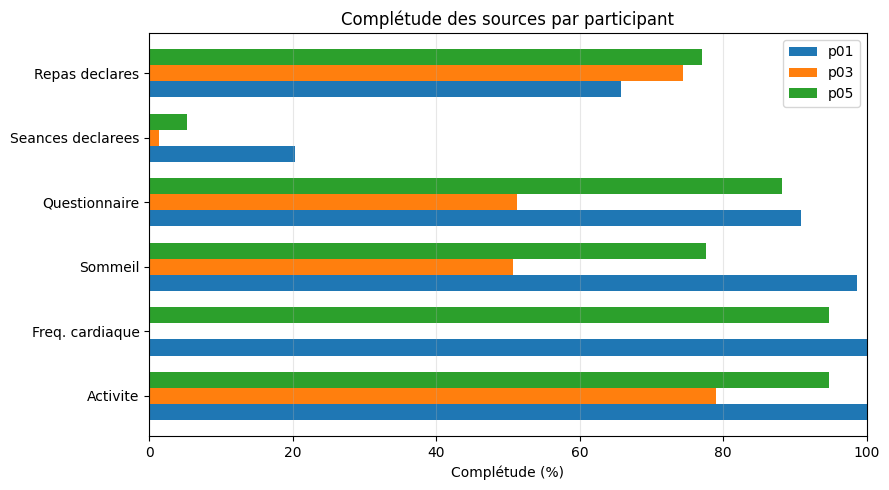

In [95]:
import matplotlib.pyplot as plt

sources = {
    "steps": "Activite",
    "hr_mean": "Freq. cardiaque",
    "sommeil_min": "Sommeil",
    "readiness": "Questionnaire",
    "srpe_total": "Seances declarees",
    "n_repas": "Repas declares",
}

comp = (df.groupby("participant")[list(sources)]
          .apply(lambda g: g.notna().mean() * 100)
          .rename(columns=sources))

ax = comp.T.plot(kind="barh", figsize=(9, 5), width=0.75)
ax.set_xlabel("Complétude (%)")
ax.set_xlim(0, 100)
ax.set_ylabel("")
ax.legend(title="")
ax.grid(axis="x", alpha=0.3)
plt.title("Complétude des sources par participant")

plt.tight_layout()
plt.savefig("figures/completude.png", dpi=150, bbox_inches="tight")
plt.show()

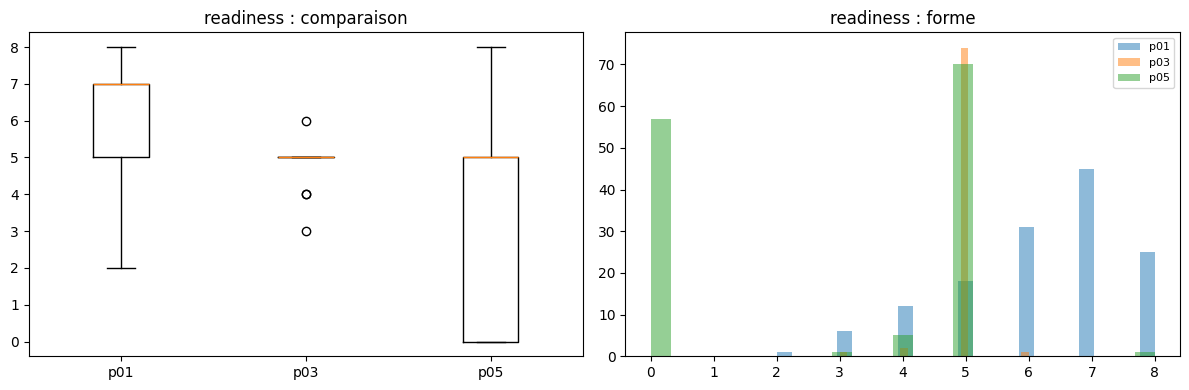

             count  mean  std  min  25%  50%  75%  max
participant                                           
p01          138.0   6.2  1.4  2.0  5.0  7.0  7.0  8.0
p03           78.0   5.0  0.3  3.0  5.0  5.0  5.0  6.0
p05          134.0   2.8  2.5  0.0  0.0  5.0  5.0  8.0


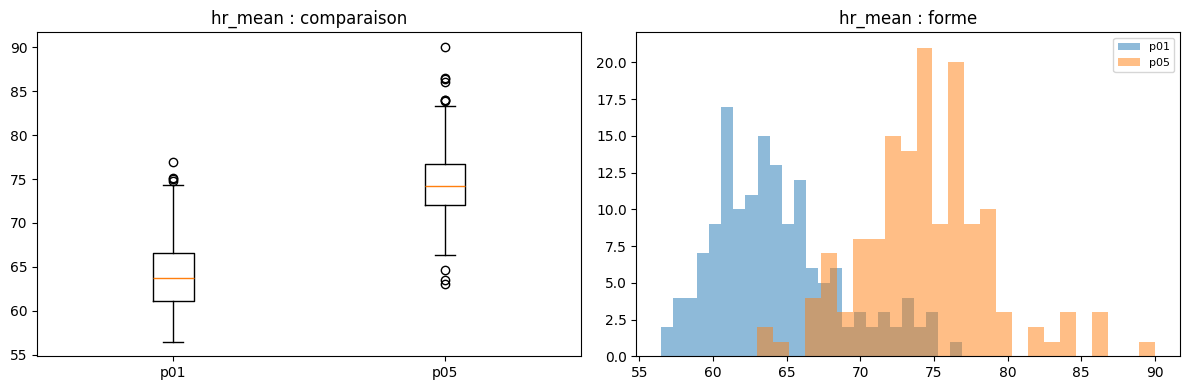

             count  mean  std   min   25%   50%   75%   max
participant                                                
p01          152.0  64.3  4.3  56.5  61.1  63.7  66.5  76.9
p05          144.0  74.4  4.5  63.0  72.0  74.2  76.7  90.0


In [96]:
"Voir ici les distribution pour avoir une idée sur une variable ou un participant"
"La variable readinesse par participant "
fig_dis("readiness")
"Exemple pour le p01 et pO5 on a une idée assez visuelle si on a des valeur aberrantes pour préparer notre pré-precessing "
fig_dis("hr_mean", ["p01", "p05"])

### Conclusion de la vue d'ensemble

456 lignes, 47 colonnes, trois participants sur 152 jours.

Trois niveaux de couverture, qui reflètent l'effort demandé au participant : les
flux du capteur (79-100 %), le sommeil et le questionnaire (51-99 %), les
déclarations ponctuelles (1-40 %).

Deux limitations structurelles : p03 n'a aucune donnée de fréquence cardiaque, et
le sRPE est renseigné sur 1 à 20 % des jours seulement. Les distributions
révèlent par ailleurs un readiness incompatible avec une échelle continue, et une
variance très faible sur fatigue et courbatures.

**Décisions.** Variables cardiaques et sRPE écartés de la modélisation. La charge
sera approchée par l'activité du capteur. Le readiness fera l'objet d'un examen
spécifique avant usage comme cible.

# Etape 4:. Data pre-processing

Trois volets, selon l'énoncé : gestion des types, détection et traitement des
valeurs aberrantes, gestion des valeurs manquantes.

### 3.2 Valeurs aberrantes

Trois familles d'anomalies, détectées différemment.

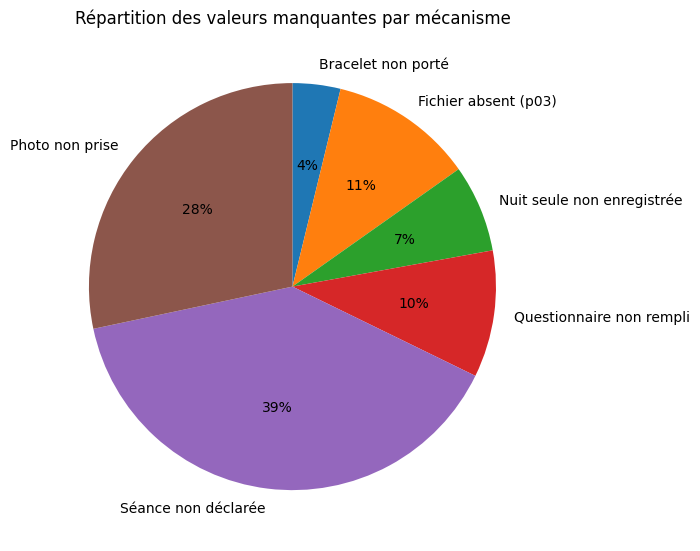

Séance non déclarée           415
Photo non prise               298
Fichier absent (p03)          120
Questionnaire non rempli      106
Nuit seule non enregistrée     73
Bracelet non porté             40


In [97]:
causes = {
    "Bracelet non porté": df["steps"].isna().sum(),
    "Fichier absent (p03)": (df["hr_mean"].isna() & df["steps"].notna()).sum(),
    "Nuit seule non enregistrée": (df["sommeil_min"].isna() & df["steps"].notna()).sum(),
    "Questionnaire non rempli": df["readiness"].isna().sum(),
    "Séance non déclarée": df["srpe_total"].isna().sum(),
    "Photo non prise": df["n_photos"].isna().sum(),
}

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(causes.values(), labels=causes.keys(), autopct="%1.0f%%",
       startangle=90, counterclock=False)
ax.set_title("Répartition des valeurs manquantes par mécanisme")
plt.tight_layout()
plt.show()

print(pd.Series(causes).sort_values(ascending=False).to_string())

In [98]:
#Valeurs physiologiquement impossibles : bornes issues de la littérature.
bornes = {
    "hr_mean":            (35, 110),
    "hr_min":             (30, 90),
    "hr_max":             (80, 220),
    "sommeil_min":        (60, 900),
    "sommeil_efficacite": (50, 100),
    "steps":              (0, 60000),
}

for col, (lo, hi) in bornes.items():
    hors = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col:22s} [{lo}, {hi}] : {hors} hors bornes   "
          f"observe [{df[col].min():.0f}, {df[col].max():.0f}]")

hr_mean                [35, 110] : 0 hors bornes   observe [56, 90]
hr_min                 [30, 90] : 0 hors bornes   observe [30, 68]
hr_max                 [80, 220] : 0 hors bornes   observe [95, 200]
sommeil_min            [60, 900] : 1 hors bornes   observe [58, 864]
sommeil_efficacite     [50, 100] : 0 hors bornes   observe [85, 100]
steps                  [0, 60000] : 0 hors bornes   observe [6, 24846]


In [99]:
#Echelle questionnaire hors bonne

echelles = {"fatigue": (1, 5), "mood": (1, 5), "sleep_quality": (1, 5),
            "soreness": (1, 5), "stress": (1, 5), "readiness": (0, 10)}

for col, (lo, hi) in echelles.items():
    hors = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col:16s} [{lo}, {hi}] : {hors} hors bornes   "
          f"observe [{df[col].min()}, {df[col].max()}]")

    # Estimation de l'apport calorique par bilan energetique.
# La depense mesuree approxime l'apport a poids stable ; elle est repartie
# selon la structure des repas declares.

poids = {"repas_breakfast": 0.25, "repas_lunch": 0.35,
         "repas_dinner": 0.30, "repas_evening": 0.10}

part = sum(df[col] * p for col, p in poids.items())
df["apport_estime"] = df["calories"] * part.replace(0, np.nan)

print(df.groupby("participant")["apport_estime"].describe().round(0))

fatigue          [1, 5] : 0 hors bornes   observe [1.0, 4.0]
mood             [1, 5] : 0 hors bornes   observe [1.0, 4.0]
sleep_quality    [1, 5] : 0 hors bornes   observe [1.0, 4.0]
soreness         [1, 5] : 0 hors bornes   observe [1.0, 4.0]
stress           [1, 5] : 0 hors bornes   observe [1.0, 4.0]
readiness        [0, 10] : 0 hors bornes   observe [0.0, 8.0]
             count    mean    std     min     25%     50%     75%     max
participant                                                              
p01          100.0  2590.0  772.0  1043.0  2037.0  2399.0  3059.0  5226.0
p03           88.0  1568.0  690.0   240.0  1205.0  1332.0  1878.0  3550.0
p05          112.0  2905.0  770.0   940.0  2470.0  3073.0  3476.0  4394.0


Bilan final :
3 profils de disponibilité se dégagent : p01 est pleinement exploitable,
p05 présente un déficit sur le sommeil, et p03 cumule l'absence de fréquence
cardiaque avec une couverture d'environ 50 % sur le sommeil et le questionnaire.

In [100]:
rapport = []

for pid in PARTICIPANTS:
    sub = df[df["participant"] == pid]
    rapport.append({
        "participant": pid,
        "jours": len(sub),
        "jours_bracelet": int(sub["fitbit_porte"].sum()),
        "freq_cardiaque": "absente" if sub["hr_mean"].isna().all() else f"{sub['hr_mean'].notna().mean()*100:.0f}%",
        "sommeil_%": round(sub["sommeil_min"].notna().mean() * 100, 1),
        "questionnaire_%": round(sub["readiness"].notna().mean() * 100, 1),
        "seances_declarees": int(sub["srpe_total"].notna().sum()),
        "photos_jours": int(sub["n_photos"].notna().sum()),
        "blessures_declarees": int(sub["blessure_declaree"].notna().sum()),
        "blessures_positives": int(sub["blessure_declaree"].sum()),
        "plus_long_trou_j": int(sub["steps"].isna().astype(int)
                                  .groupby((sub["steps"].notna()).cumsum()).sum().max()),
    })

pd.DataFrame(rapport).T

,0,1,2
participant,p01,p03,p05
jours,152,152,152
jours_bracelet,152,120,144
freq_cardiaque,100%,absente,95%
sommeil_%,98.7,50.7,77.6
questionnaire_%,90.8,51.3,88.2
seances_declarees,31,2,8
photos_jours,60,51,47
blessures_declarees,24,11,10
blessures_positives,1,0,10


3.3 Traitement des valeurs manquantes

Deux questions avant de remplacer : quelle cause, et à partir de quel taux
l'imputation cesse d'être défendable ?

La littérature stratifie selon le taux (Kim et Kim, 2020 ; Benson et al., 2021).
Deux critères s'y ajoutent ici : l'autocorrélation à un jour, qui conditionne la
propagation de la dernière valeur connue, et l'existence d'une valeur vraie à
approcher.

Sur ce dernier point, trois cas : grandeurs physiologiquement contraintes
(imputables), grandeurs à large amplitude comme les pas (incertitude forte), et
variables déclaratives ( repas, séances, photos ) dont l'absence ne recouvre
aucune valeur vraie.

In [101]:
#fixer un seuil pour savoir si possible ou non d'imputer , autocorrelation veille
#choix des variables à imputer si possible
variables = ["hr_mean", "readiness", "fatigue", "sommeil_min",
             "steps", "soreness", "sleep_quality"]

for col in variables:
    r = (df.groupby("participant")[col]
           .apply(lambda s: s.autocorr(lag=1))
           .mean())
    print(f"{col:16s} r = {r:.2f}")

    candidates = ["steps", "sommeil_min", "sommeil_efficacite", "hr_mean",
              "fatigue", "soreness", "sleep_quality", "readiness",
              "n_repas", "glasses_of_fluid", "srpe_total", "n_photos"]
#fixation des seuils
decision = []
for col in candidates:
    taux = df[col].isna().mean() * 100
    auto = df.groupby("participant")[col].apply(lambda s: s.autocorr(lag=1)).mean()

    if taux > 60:
        choix = "ecartee"
    elif taux > 30:
        choix = "a discuter"
    else:
        choix = "imputable"
#autocorrelation pour voir si les valeurs se ressemblent d'un jour à l'autre
    decision.append({
        "variable": col,
        "manquants_%": round(taux, 1),
        "autocorr_1j": round(auto, 2),
        "statut": choix,
    })

pd.DataFrame(decision).sort_values("manquants_%")

hr_mean          r = 0.26
readiness        r = 0.49
fatigue          r = 0.21
sommeil_min      r = 0.03
steps            r = 0.28
soreness         r = 0.18
sleep_quality    r = 0.27


C:\Users\ghiattka\AppData\Roaming\Python\Python310\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\ghiattka\AppData\Roaming\Python\Python310\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


,variable,manquants_%,autocorr_1j,statut
0,steps,8.8,0.28,imputable
4,fatigue,23.2,0.21,imputable
5,soreness,23.2,0.18,imputable
6,sleep_quality,23.2,0.27,imputable
7,readiness,23.2,0.49,imputable
1,sommeil_min,24.3,0.03,imputable
2,sommeil_efficacite,24.3,0.23,imputable
8,n_repas,27.6,0.29,imputable
9,glasses_of_fluid,27.6,0.30,imputable
3,hr_mean,35.1,0.26,a discuter


3.4 Méthodes disponibles au-dessus du seuil fixé

Lorsque le taux de manquants reste sous le seuil retenu, plusieurs approches
sont documentées. De la plus élaborée à la plus simple :

**Imputation multiple** : génère plusieurs versions du jeu de données et combine
les analyses, ce qui propage l'incertitude d'imputation jusqu'aux résultats.

**Plus proches voisins (KNN)** :moyenne des observations les plus ressemblantes
sur les autres variables.

**Interpolation temporelle** : estimation à partir des valeurs encadrantes.

**Médiane par participant** : valeur centrale individuelle.

**Suppression des lignes incomplètes** :aucune estimation.

In [ ]:
#Exemple si on regarde uné methode d'interpolation linéaire/cubique
# Resultat : ca peut creer des valeur complétement abérrantes
col = "sommeil_efficacite"
porte = df["fitbit_porte"] == 1

df[f"{col}_lin"] = df[col]
df.loc[porte, f"{col}_lin"] = (df.loc[porte].groupby("participant")[col]
                                 .transform(lambda s: s.interpolate(method="linear", limit=2)))

df[f"{col}_cub"] = df[col]
df.loc[porte, f"{col}_cub"] = (df.loc[porte].groupby("participant")[col]
                                 .transform(lambda s: s.interpolate(method="cubic", limit=2)))

print(df[[col, f"{col}_lin", f"{col}_cub"]].describe().round(2))
# Pour la fréquence cardiaque, chez les deux athletes, ils ont toutes les valeurs
col = "hr_mean"
porte = df["fitbit_porte"] == 1

df[f"{col}_lin"] = df[col]
df.loc[porte, f"{col}_lin"] = (df.loc[porte].groupby("participant")[col]
                                 .transform(lambda s: s.interpolate(method="linear", limit=2)))

df[f"{col}_cub"] = df[col]
df.loc[porte, f"{col}_cub"] = (df.loc[porte].groupby("participant")[col]
                                 .transform(lambda s: s.interpolate(method="cubic", limit=2)))

print(df[[col, f"{col}_lin", f"{col}_cub"]].describe().round(2))

## Conclusion de cette partie

**Types.** Formats incohérents harmonisés au chargement : dates jour/mois,
booléens en deux vocabulaires, structures imbriquées.

**Valeurs fausses.** Calories générées par Fitbit les jours sans port,
questionnaires envoyés vides, six nuits longues conservées après vérification.

**Valeurs manquantes.** Cinq méthodes testées. La médiane écrase la variabilité
de 13 %, l'imputation multivariée n'apporte rien, la recopie de la veille n'est
pas justifiée (autocorrélation ≤ 0,28), l'interpolation cubique sort du domaine.
Seule l'interpolation linéaire tient, sur l'efficacité du sommeil : 42 valeurs.

**Livrable.** `test_dataset.csv` conserve les manquants. L'imputation se fait
dans le pipeline de modélisation, fold par fold.


## Étape 4 — Modélisation

Feature engineering : construire des variables plus explicatives que les mesures
brutes.

# 4.1 Construction des variables

Les valeurs brutes quotidiennes rendent mal compte de deux phénomènes établis en
sciences du sport : l'accumulation de charge sur plusieurs jours, et l'écart d'un
individu à sa propre norme.

**Charge d'entraînement.** Le sRPE étant inexploitable (1 à 20 % de complétude),
la charge est approchée par le volume d'activité du capteur. Trois indicateurs
sont construits : charge aiguë sur 7 jours, charge chronique sur 28 jours, et
leur ratio (ACWR).

L'ACWR fait l'objet de critiques méthodologiques : Impellizzeri et al. (2020)
concluent qu'aucune preuve ne soutient son usage et identifient un couplage
mathématique entre numérateur et dénominateur. Il est conservé à titre
conventionnel, les charges brutes restant les prédicteurs principaux.

**Dette de sommeil.** Une revue de 2021 identifie sept heures ou moins comme le
seuil associé à un risque accru, l'association apparaissant lorsque le déficit
est maintenu sur au moins quatorze jours (risque 1,7 fois supérieur). La variable
cumule donc, sur une fenêtre glissante de 14 jours, l'écart au seuil de 420
minutes pour les nuits déficitaires.

Toutes ces variables sont décalées d'un jour car quand on predit un score, on a pas les données du jour.

**Cible** : état de blessure.
**Prédicteurs** : charge aiguë et chronique, ACWR, dette de sommeil, activité,
sommeil, nutrition.

In [ ]:
df = df.sort_values(["participant", "date"]).reset_index(drop=True)
g = df.groupby("participant")

df["charge_7j"] = (g["steps"].shift(1).rolling(7, min_periods=4).sum()
                     .reset_index(level=0, drop=True))
df["charge_28j"] = (g["steps"].shift(1).rolling(28, min_periods=14).sum()
                      .reset_index(level=0, drop=True))
df["acwr"] = df["charge_7j"] / (df["charge_28j"] / 4)

df["dette_sommeil"] = (g["sommeil_min"].shift(1).rolling(14, min_periods=7)
                         .apply(lambda s: (420 - s).clip(lower=0).sum())
                         .reset_index(level=0, drop=True))

print(df[["charge_7j", "charge_28j", "acwr", "dette_sommeil"]].describe().round(1))

 4.2 Construction de l'indice de readiness

Le jeu de données ne contient pas mesure de performance sportive. L'indice
développé est donc un indicateur de disponibilité perçue, proxy de la capacité à
performer, et non une mesure de performance.

**La variable directe n'est pas exploitable.** Le questionnaire contient une
question de readiness sur 0-10. Après correction des zéros — qui se concentrent
chez p05 en novembre-décembre, avant sa période de blessure, et correspondent
donc à un champ non renseigné — l'écart-type est de 1,41 chez p01 mais de 0,30
et 0,48 chez p03 et p05. La variable ne varie que chez un participant sur trois.

**Sélection des dimensions.** Un indice composite est construit selon l'approche
de Hooper et Mackinnon (1995). Les dimensions sont retenues sur la base de leur
association avec le readiness déclaré chez p01, seul participant où il varie :
courbatures 0,61, fatigue 0,60, qualité du sommeil 0,27. Stress (−0,15) et
humeur (0,01) sont écartés.

Cette analyse révèle un point non documenté : pour la fatigue et les courbatures,
une valeur élevée correspond à un meilleur état — l'échelle mesure l'absence de
symptôme. Une inversion intuitive produisait une corrélation de −0,56. Saw et al.
(2016) relèvent précisément que la direction de ces échelles varie selon les
études.

**Validation.** L'indice corrèle à 0,66 avec la question directe chez p01, sans
l'utiliser. Il peut donc être appliqué aux trois participants. Gain de
couverture : 134 jours chez p05 contre 77. Gain de variabilité : écart-type de
7,1 contre 0,48.

Sansone et al. (2023) relèvent que 11 des 15 études de leur revue utilisaient des
mesures non validées, et concluent qu'une validation préalable est indispensable.

In [ ]:
#  La question directe de readiness n'est pas exploitable telle quelle
df.loc[df["readiness"] == 0, "readiness"] = np.nan
print(df.groupby("participant")["readiness"].agg(["count", "mean", "std"]).round(2))
#  Direction de l'echelle, determinee par correlation avec le readiness
# chez p01, seul participant ou la variable varie
p01 = df[df["participant"] == "p01"]
cols = ["mood", "sleep_quality", "fatigue", "soreness", "stress", "readiness"]
print(p01[cols].corr(method="spearman")["readiness"].round(2))
# Construction de l'indice et validation
dims = ["fatigue", "soreness", "sleep_quality"]
df["indice_wellness"] = df[dims].mean(axis=1) / 5 * 100
#Construction de l'indice et validation
p01 = df[df["participant"] == "p01"]
print(p01[["indice_wellness", "readiness"]].corr(method="spearman").round(2))
print(df.groupby("participant")["indice_wellness"]
        .agg(["count", "mean", "std", "min", "max"]).round(1))

4.3 Analyse bivariée

Avant de modéliser, quelles variables objectives s'associent à l'indice ?
L'analyse est conduite par participant : une corrélation calculée sur les trois
sujets confondus capterait surtout leurs différences de niveau plutôt que la
relation intra-individuelle.
Resultats :Pour six variables sur dix, le signe s'inverse selon le participant. Seules
l'ACWR et la dette de sommeil restent négatives chez tous : cohérent avec une
dégradation de l'état perçu sous charge élevée. Cette hétérogénéité annonce la difficulté d'une validation inter-participants.

In [ ]:
predicteurs = ["steps", "charge_7j", "charge_28j", "acwr", "dette_sommeil",
               "sommeil_min", "sommeil_efficacite", "hr_mean",
               "ex_duree_min", "n_repas", "glasses_of_fluid"]

# correlation de Spearman entre predicteurs et indice de wellness, par participant
corr = pd.DataFrame({
    pid: (df[df["participant"] == pid][predicteurs + ["indice_wellness"]]
            .corr(method="spearman")["indice_wellness"].drop("indice_wellness"))
    for pid in PARTICIPANTS
})

print(corr.round(2).to_string())

ax = corr.plot(kind="barh", figsize=(9, 6), width=0.75)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Corrélation de Spearman avec l'indice")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)
plt.title("Association des prédicteurs avec l'indice, par participant")
plt.tight_layout()
plt.savefig("figures/correlations_participant.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Cible prospective : blessure survenant dans les 7 jours suivants

decl = []
for pid in PARTICIPANTS:
    inj = pd.read_csv(base / pid / "pmsys" / "injury.csv")
    inj["date"] = (pd.to_datetime(inj["effective_time_frame"], utc=True)
                     .dt.tz_localize(None).dt.normalize())
    inj = inj[inj["injuries"] != "{}"][["date"]].copy()
    inj["participant"] = pid
    inj["evenement"] = 1
    decl.append(inj)

evenements = pd.concat(decl).sort_values("date")

base_dates = df[["participant", "date"]].sort_values("date").reset_index()

cible = pd.merge_asof(
    base_dates,
    evenements.sort_values("date"),
    on="date", by="participant",
    direction="forward", tolerance=pd.Timedelta("7D"),
)

df["blessure_7j"] = (cible.set_index("index")["evenement"]
                          .reindex(df.index)
                          .fillna(0).astype(int))

print(df.groupby("participant")["blessure_7j"].agg(["sum", "mean"]).round(3))

 4.3 Protocole de validation et choix des modèles

**Validation.** LOPO est retenu : les 152 jours d'un même
participant partagent sa physiologie et son niveau de base, donc les observations
ne sont pas indépendantes. Un découpage aléatoire permettrait au modèle de
reconnaître l'individu et surestimerait la performance.

Avec 3 participants, chaque modèle est entraîné sur deux sujets et testé sur
le troisième. Les folds ne sont pas équivalents : p01 a une couverture quasi
complète, p03 ni fréquence cardiaque ni la moitié de son questionnaire
 == ce qui rend leur moyenne peu interprétable. Le protocole reste préférable à un
découpage aléatoire.

**Modèles.** Deux familles par cible. Un modèle linéaire régularisé comme
référence : peu de paramètres, pas de surapprentissage sur petits effectifs,
coefficients interprétables. Une forêt aléatoire pour capter d'éventuelles
relations non linéaires.

Les paramètres sont fixés a priori : trois folds ne permettent pas de recherche
d'hyperparamètres sans surapprentissage.

**Métriques.** MAE et R² pour la régression, comparés à une prédiction constante.
PR-AUC comparée à la prévalence pour la classification, la ROC-AUC étant
optimiste sur classes déséquilibrées.

Modèle 1 :  Indice de readiness

Preparation des données

In [ ]:
FEATURES = ["steps", "charge_7j", "charge_28j", "acwr", "dette_sommeil",
            "sommeil_min", "sommeil_efficacite", "ex_duree_min",
            "ex_n_seances", "n_repas", "glasses_of_fluid"]

d = df.sort_values(["participant", "date"]).copy()
for f in FEATURES:
    d[f] = d.groupby("participant")[f].shift(1)

print(f"{d[FEATURES].notna().all(axis=1).sum()} lignes completes sur {len(d)}")

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

m = d.dropna(subset=["indice_wellness"]).copy()
X, y, g = m[FEATURES], m["indice_wellness"], m["participant"]

reference = m.groupby("participant")["indice_wellness"].transform("mean")
print(f"{'Reference':22s} MAE {mean_absolute_error(y, reference):5.2f}  R2 {r2_score(y, reference):6.3f}")

for nom, mod in [("Ridge", Ridge(alpha=1.0)),
                 ("Random Forest", RandomForestRegressor(n_estimators=300,
                                    min_samples_leaf=5, random_state=0))]:
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc", StandardScaler()), ("m", mod)])
    pred = cross_val_predict(pipe, X, y, groups=g, cv=LeaveOneGroupOut())
    print(f"{nom:22s} MAE {mean_absolute_error(y, pred):5.2f}  R2 {r2_score(y, pred):6.3f}")

In [ ]:
# Normalisation de la cible par participant : le modele predit l'ecart
# a la norme individuelle plutot que le niveau absolu, les niveaux
# differant entre sujets (52,2 / 59,2 / 56,3).
m["indice_z"] = m.groupby("participant")["indice_wellness"].transform(
    lambda s: (s - s.mean()) / s.std())
y_z = m["indice_z"]

for nom, mod in [("Ridge", Ridge(alpha=1.0)),
                 ("Random Forest", RandomForestRegressor(n_estimators=300,
                                    min_samples_leaf=5, random_state=0))]:
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc", StandardScaler()), ("m", mod)])
    pred = cross_val_predict(pipe, X, y_z, groups=g, cv=LeaveOneGroupOut())
    print(f"{nom:16s} MAE {mean_absolute_error(y_z, pred):5.2f}  R2 {r2_score(y_z, pred):6.3f}")

In [ ]:
# Ajout de l'etat de la veille comme predicteur : un indice de bien-etre est
# fortement autocorrele, la valeur d'hier peut porter plus d'information que
# les mesures objectives du capteur.
m["indice_z"] = m.groupby("participant")["indice_wellness"].transform(
    lambda s: (s - s.mean()) / s.std())
m["indice_veille"] = m.groupby("participant")["indice_wellness"].shift(1)
m2 = m.dropna(subset=["indice_veille"])


X2 = m2[FEATURES + ["indice_veille"]]
y2 = m2["indice_z"]
g2 = m2["participant"]

pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                 ("sc", StandardScaler()), ("m", Ridge(alpha=1.0))])
pred = cross_val_predict(pipe, X2, y2, groups=g2, cv=LeaveOneGroupOut())
print(f"Ridge + veille   MAE {mean_absolute_error(y2, pred):5.2f}  R2 {r2_score(y2, pred):6.3f}")

#### Conclusion du Modèle 1

Aucune configuration fondée sur les seules variables objectives ne dépasse la
référence. Le R² ne devient positif qu'avec l'ajout de l'état de la veille
(0,029), et reste très faible.

Trois facteurs expliquent ce résultat.

La validation leave-one-participant-out, seule défendable avec des données
groupées, entraîne le modèle sur deux sujets pour le tester sur un troisième.
Avec trois participants, ce qui est partagé par deux ne se transpose pas
nécessairement au troisième.

L'analyse bivariée a montré que six variables sur dix changent de signe selon le
participant : il n'existe pas de relation commune à tous.

Enfin, l'objet même de la prédiction pose question. Il s'agit d'estimer un
ressenti déclaré à partir de mesures physiologiques et comportementales. Les
deux ne captent pas nécessairement le même phénomène.

 Modèle 2 : Risque de blessure

Deux formulations de la cible ont été testées.

** Cible 1 : État courant** : chaque déclaration est propagée sur 14 jours, durée
correspondant aux écarts observés entre déclarations consécutives chez p05
(1 à 15 jours). Le modèle répond alors à « ce joueur est-il blessé aujourd'hui ».

**Cible 2 : Risque prospectif** : blessure survenant dans les 7 jours suivants, construite
par jointure temporelle. Formulation plus conforme à un usage opérationnel : elle
répond à « ce joueur risque-t-il de se blesser ».

Cible 1 :Etat courant

In [ ]:
# Preparation : on ne garde que les jours ou l'etat est renseigne

bless = d.dropna(subset=["blessure_etat"]).copy()
Xb = bless[FEATURES]
yb = bless["blessure_etat"].astype(int)
gb = bless["participant"]
# Pipeline : imputation et standardisation apprises fold par fold,
# ponderation des classes pour compenser le desequilibre (27 % de positifs)
pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                 ("sc", StandardScaler()),
                 ("m", LogisticRegression(class_weight="balanced", max_iter=1000))])
# Validation leave-one-participant-out : entraine sur deux sujets, teste sur le troisieme
proba = cross_val_predict(pipe, Xb, yb, groups=gb,
                          cv=LeaveOneGroupOut(), method="predict_proba")[:, 1]
# Metriques : la PR-AUC se lit par rapport a la prevalence, non a 0,5

bless["proba"] = proba

print(f"ROC-AUC : {roc_auc_score(yb, proba):.3f}")
print(f"PR-AUC  : {average_precision_score(yb, proba):.3f}  (prevalence {yb.mean():.3f})")
print(bless.groupby("participant")["proba"].agg(["mean", "std"]).round(3))

Cible 2 : Risque prospectif

In [ ]:
b7 = d.copy()
b7["blessure_7j"] = df["blessure_7j"].values

X7, y7, g7 = b7[FEATURES], b7["blessure_7j"], b7["participant"]

pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                 ("sc", StandardScaler()),
                 ("m", LogisticRegression(class_weight="balanced", max_iter=1000))])

proba7 = cross_val_predict(pipe, X7, y7, groups=g7,
                           cv=LeaveOneGroupOut(), method="predict_proba")[:, 1]

print(f"ROC-AUC : {roc_auc_score(y7, proba7):.3f}")
print(f"PR-AUC  : {average_precision_score(y7, proba7):.3f}  (prevalence {y7.mean():.3f})")

Cible 1 : metriques choisis

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

SEUIL = 0.5 # seuil par defaut ; arbitraire sur classes desequilibrees
pred = (proba >= SEUIL).astype(int)

print("Matrice de confusion (lignes = reel, colonnes = predit)")
print(confusion_matrix(yb, pred))
print()
print(classification_report(yb, pred, target_names=["sain", "blesse"],
                            digits=3, zero_division=0))




In [ ]:
# ---- Effet du seuil sur le volume d'alertes -
for s in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    p = (proba >= s).astype(int)
    vp = ((p == 1) & (yb == 1)).sum()
    fp = ((p == 1) & (yb == 0)).sum()
    fn = ((p == 0) & (yb == 1)).sum()
    prec = vp / (vp + fp) if vp + fp else 0
    rapp = vp / (vp + fn) if vp + fn else 0
    print(f"seuil {s:.1f} : {p.sum():3d} alertes | precision {prec:.2f} | rappel {rapp:.2f}")

In [ ]:
# Cible 1 : distribution des probabilites predites ---------------------

fig, ax = plt.subplots(figsize=(8, 4))

for pid in PARTICIPANTS:
    sub = bless[bless["participant"] == pid]
    ax.hist(sub["proba"], bins=25, alpha=0.5,
            label=f"{pid} (blessé {sub['blessure_etat'].mean()*100:.0f}% du temps)")

ax.set_xlabel("Probabilité prédite de blessure")
ax.set_ylabel("Jours")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.title("Probabilités prédites par participant")
plt.tight_layout()
plt.savefig("figures/proba_blessure.png", dpi=150, bbox_inches="tight")
plt.show()

Cible 2 : Metriques utilsés

In [ ]:

pred7 = (proba7 >= 0.5).astype(int)

print("Matrice de confusion (lignes = reel, colonnes = predit)")
print(confusion_matrix(y7, pred7))
print()
print(classification_report(y7, pred7, target_names=["sain", "blesse"],
                            digits=3, zero_division=0))

In [ ]:
# ---- Cible 2 : effet du seuil sur le volume d'alertes ---------------------

for s in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    p = (proba7 >= s).astype(int)
    vp = ((p == 1) & (y7 == 1)).sum()
    fp = ((p == 1) & (y7 == 0)).sum()
    fn = ((p == 0) & (y7 == 1)).sum()
    prec = vp / (vp + fp) if vp + fp else 0
    rapp = vp / (vp + fn) if vp + fn else 0
    print(f"seuil {s:.1f} : {p.sum():3d} alertes | precision {prec:.2f} | rappel {rapp:.2f}")

In [ ]:
# ---- Cible 2 : distribution des probabilites predites ---------------------

b7["proba7"] = proba7

fig, ax = plt.subplots(figsize=(8, 4))
for pid in PARTICIPANTS:
    sub = b7[b7["participant"] == pid]
    ax.hist(sub["proba7"], bins=25, alpha=0.5,
            label=f"{pid} ({sub['blessure_7j'].mean()*100:.0f}% de jours positifs)")

ax.set_xlabel("Probabilité prédite de blessure à 7 jours")
ax.set_ylabel("Jours")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.title("Probabilités prédites par participant — cible prospective")
plt.tight_layout()
plt.savefig("figures/proba_blessure_7j.png", dpi=150, bbox_inches="tight")
plt.show()

Sauvegarde automatique de test_dataset.csv

In [ ]:
cols = ["participant", "date"] + [c for c in df.columns if c not in ("participant", "date")]
df[cols].to_csv("test_dataset.csv", index=False)
print(f"test_dataset.csv : {df.shape[0]} lignes, {df.shape[1]} colonnes")

## Conclusion

**Ce qui fonctionne.** L'agrégation des sept sources produit une table
exploitable de 456 lignes. L'indice de readiness est validé empiriquement
(r = 0,66 avec la question directe).

**Ce qui ne fonctionne pas.** La prédiction de blessure repose sur quatre
épisodes distincts, aucun de type surcharge, et des protocoles de déclaration
hétérogènes. Le modèle discrimine les individus, pas un état physiologique.

La prédiction de readiness ne dépasse la référence qu'en ajoutant l'état de la
veille (R² = 0,029). Pour six variables sur dix, le signe de l'association
s'inverse selon le participant.

**Ce qu'il faudrait.** Un effectif suffisant, un protocole de déclaration
homogène, une distinction des mécanismes lésionnels, et une mesure de
performance.

Analyse détaillée et références dans le rapport joint.